<a href="https://colab.research.google.com/github/Rahulrama6705/Stock-Price-Prediction-using-LSTM/blob/main/Stock_Price_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance
!pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [3]:
stock = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

stock = stock[['Close']]
stock.head()

/tmp/ipython-input-3283870664.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.214895
2015-01-05,23.532721
2015-01-06,23.534933
2015-01-07,23.864948
2015-01-08,24.781887


In [4]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(stock)

In [5]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape for LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [6]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0207
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.4880e-04
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.3822e-04
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.3270e-04
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.6941e-04
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.2074e-04
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5674e-04
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.0433e-04
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.4569e-04
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.7665e-04


In [9]:
predictions = model.predict(X_test)

# Convert back to original scale
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


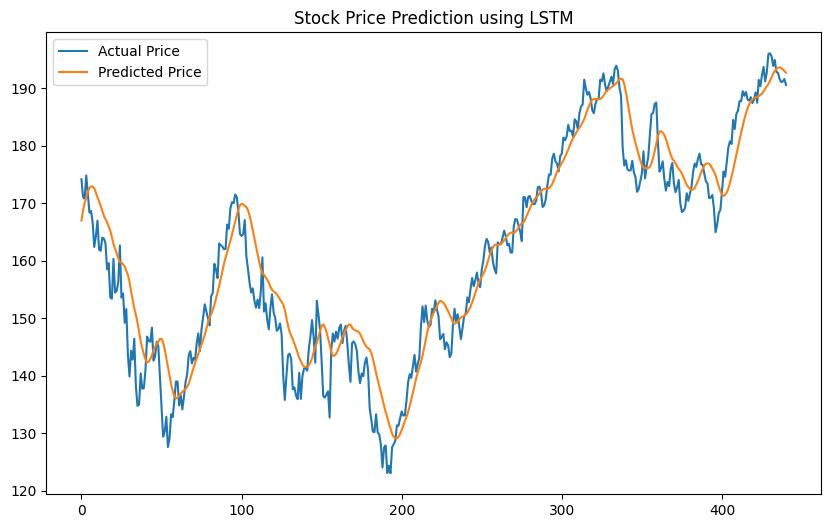

In [10]:
plt.figure(figsize=(10,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction using LSTM")
plt.show()